# Handwritten Digit Recognition — End-to-End (Google Colab)

This notebook does all three parts of the project, in order:

1. **Prepare the dataset** — take your raw photos and turn them into a clean,
   labeled, model-ready dataset.
2. **Train & evaluate a small CNN**.
3. **Deploy** — export the trained model to a self-contained, working HTML
   demo you can open in any browser (draw a digit, get a live prediction).

Pipeline implemented in Step 2:

```
RAW PHOTOS
  → Quality control
  → Crop digit
  → Grayscale
  → Lighting/background normalization
  → Center digit
  → Resize → 32×32
  → Normalize → [0,1]
  → Train/Validation/Test split
  → Augmentation ONLY on training
  → CNN training
  → Evaluation on untouched test set
```

**Before you run this**: put ~50–100 photos per digit (0–9) into a single
`.rar` or `.zip` archive, one photo per file, and be ready to upload it in
Step 1.



## Step 0 — Install / import dependencies

Colab already has TensorFlow, OpenCV, and scikit-learn. We only need `unrar` (for `.rar` archives) if your upload is a `.rar` file.

In [1]:
!apt-get -qq install -y unrar > /dev/null

import os, re, json, shutil, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)


TensorFlow: 2.20.0
OpenCV: 5.0.0


## Step 1 — Upload and extract your raw photos

Run the cell below, then click **Choose Files** and select your `.rar` or
`.zip` archive of raw digit photos.


In [16]:
from google.colab import files

print("Select your .rar or .zip archive of raw digit photos:")
uploaded = files.upload()
archive_name = list(uploaded.keys())[0]
print("Uploaded:", archive_name)

RAW_EXTRACT_DIR = "/content/raw_extracted"
os.makedirs(RAW_EXTRACT_DIR, exist_ok=True)

if archive_name.lower().endswith(".rar"):
    !unrar x -o+ "{archive_name}" "{RAW_EXTRACT_DIR}/" > /dev/null
elif archive_name.lower().endswith(".zip"):
    with zipfile.ZipFile(archive_name, "r") as z:
        z.extractall(RAW_EXTRACT_DIR)
else:
    raise ValueError("Please upload a .rar or .zip archive")

# Find the folder that actually contains the .jpg/.png files (archives often
# wrap everything in one extra top-level folder)
candidates = []
for root, _, fnames in os.walk(RAW_EXTRACT_DIR):
    if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in fnames):
        candidates.append(root)
RAW_PHOTOS_DIR = max(candidates, key=lambda d: len(os.listdir(d)))
n_photos = len([f for f in os.listdir(RAW_PHOTOS_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
print(f"Found {n_photos} photos in: {RAW_PHOTOS_DIR}")


Select your .rar or .zip archive of raw digit photos:


Saving Project AI.rar to Project AI (2).rar
Uploaded: Project AI (2).rar
Found 587 photos in: /content/raw_extracted/Project AI


## Step 1b — Map filenames to digit labels

Every dataset gets photographed and named a bit differently, so this cell
needs to know how to turn a filename into a label 0–9. The default below
covers the common patterns:

- a leading digit directly (`3_014.jpg`, `7 (12).jpg` → label from the
  leading digit run)
- a "batch prefix" pattern like `20001 (4).jpg` meaning digit **2**, or
  `40001`, `60001` meaning **4**, **6** (i.e. a leading digit followed by
  trailing zeros from a second photo batch)

**If your filenames don't follow any recognizable pattern**, the simplest
fix is to skip this cell and instead upload an archive that already has
one subfolder per digit (`0/`, `1/`, ... `9/`) — then just set
`RAW_LABELED_DIR = RAW_PHOTOS_DIR` and skip straight to Step 2.


In [17]:
def guess_label(fname):
    """Best-effort filename -> digit label ('0'-'9') or None."""
    stem = os.path.splitext(fname)[0]

    # pattern: leading digits then optional " (n)" copy-suffix, e.g. "20001 (4)"
    m = re.match(r"^(\d+)\s*(\(\d+\))?$", stem)
    if m:
        prefix = m.group(1)
        if prefix.endswith("0001") and len(prefix) > 4:
            return prefix[0]
        if prefix.endswith("001") and len(prefix) > 3:
            return prefix[0]
        if len(prefix) == 1:
            return prefix

    # pattern: "<digit>_<anything>", e.g. "0_014"
    m = re.match(r"^(\d)_", stem)
    if m:
        return m.group(1)

    # fallback: first digit character anywhere in the filename
    m = re.search(r"\d", stem)
    return m.group(0) if m else None


RAW_LABELED_DIR = "/content/raw_labeled"
for d in "0123456789":
    os.makedirs(os.path.join(RAW_LABELED_DIR, d), exist_ok=True)

counts, unmatched = {d: 0 for d in "0123456789"}, []
for fname in os.listdir(RAW_PHOTOS_DIR):
    if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
    label = guess_label(fname)
    if label not in counts:
        unmatched.append(fname)
        continue
    shutil.copy2(os.path.join(RAW_PHOTOS_DIR, fname),
                 os.path.join(RAW_LABELED_DIR, label, fname))
    counts[label] += 1

print("Per-class raw counts:", counts, " total:", sum(counts.values()))
if unmatched:
    print(f"\n{len(unmatched)} files could not be auto-labeled, e.g.:", unmatched[:10])
    print("Fix these by renaming them or moving them manually into",
          RAW_LABELED_DIR, "/<digit>/ before continuing.")


Per-class raw counts: {'0': 40, '1': 49, '2': 80, '3': 41, '4': 88, '5': 80, '6': 69, '7': 42, '8': 49, '9': 49}  total: 587


## Step 2 — Preprocessing pipeline

`RAW PHOTOS → Quality control → Crop digit → Grayscale → Lighting/background
normalization → Center digit → Resize (32×32) → Normalize [0,1]`

Real phone photos vary a lot — some are tight shots of just the paper,
others are wide desk photos with the sheet sitting on a table. So the
pipeline works in two stages:

1. **Locate the paper** in the frame (if it's a wide shot) and crop to it.
2. **Find the ink** within the paper using adaptive thresholding +
   connected-component filtering, so JPEG noise, paper texture, and shadows
   don't get mistaken for the digit.


In [18]:
IMG_SIZE = 32
PAD_FRAC = 0.25
WORK_MAX_DIM = 900


def quality_control(gray):
    """Reject unreadable / near-blank images before we try to find a digit."""
    if gray is None or gray.size == 0:
        return False, "empty image"
    if gray.std() < 3:
        return False, f"near-uniform image, likely blank/corrupt ({gray.std():.1f})"
    return True, "ok"


def _downscale(gray):
    h, w = gray.shape
    m = max(h, w)
    if m <= WORK_MAX_DIM:
        return gray
    scale = WORK_MAX_DIM / m
    return cv2.resize(gray, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)


def locate_paper(gray):
    """Crop a wide desk photo down to just the paper. No-op if the paper
    already fills the frame."""
    h, w = gray.shape
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, bright = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(bright, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return gray

    x, y, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
    if (bw * bh) / (w * h) > 0.85:
        return gray  # already just the paper

    mx, my = int(bw * 0.06), int(bh * 0.06)
    x0, y0 = max(0, x + mx), max(0, y + my)
    x1, y1 = min(w, x + bw - mx), min(h, y + bh - my)
    if x1 - x0 < 20 or y1 - y0 < 20:
        return gray
    return gray[y0:y1, x0:x1]


def find_ink_mask(gray):
    """Adaptive threshold + connected-component filtering to isolate the
    actual ink strokes from noise/paper edges. Returns a binary mask
    (ink = 255) or None."""
    h, w = gray.shape
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    block = max(15, (min(h, w) // 4) | 1)
    th = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, blockSize=block, C=7)

    kernel = np.ones((3, 3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(th, connectivity=8)
    if n_labels <= 1:
        return None

    min_area = max(8, int(0.0008 * h * w))
    keep = np.zeros_like(th)
    for i in range(1, n_labels):
        x, y, bw, bh, area = stats[i]
        if area < min_area:
            continue
        touches_border = x <= 1 or y <= 1 or (x + bw) >= w - 1 or (y + bh) >= h - 1
        if touches_border and area < 0.02 * h * w:
            continue  # leftover paper edge / shadow, not ink
        keep[labels == i] = 255

    return keep if keep.sum() > 0 else None


def center_and_resize(mask, bbox, size=IMG_SIZE, pad_frac=PAD_FRAC):
    """Crop to the ink bounding box (+padding), center on a square canvas,
    resize to size x size — MNIST-style centering."""
    x0, y0, x1, y1 = bbox
    w, h = x1 - x0 + 1, y1 - y0 + 1
    side = max(int(max(w, h) * (1 + pad_frac)), 1)
    cx, cy = (x0 + x1) // 2, (y0 + y1) // 2

    canvas = np.zeros((side, side), dtype=np.uint8)
    half = side // 2
    sx0, sy0, sx1, sy1 = cx - half, cy - half, cx - half + side, cy - half + side
    H, W = mask.shape
    dx0, dy0 = 0, 0
    if sx0 < 0: dx0, sx0 = -sx0, 0
    if sy0 < 0: dy0, sy0 = -sy0, 0
    sx1, sy1 = min(sx1, W), min(sy1, H)
    cw, ch = sx1 - sx0, sy1 - sy0
    if cw > 0 and ch > 0:
        canvas[dy0:dy0 + ch, dx0:dx0 + cw] = mask[sy0:sy1, sx0:sx1]

    return cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)


def process_one(path, min_ink_px=25):
    """Run the full pipeline on one image. Returns (float32 32x32 array in
    [0,1], None) on success, or (None, reject_reason) on failure."""
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None, "unreadable file"

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    ok, reason = quality_control(gray)
    if not ok:
        return None, reason

    gray = _downscale(gray)
    paper = locate_paper(gray)
    mask = find_ink_mask(paper)
    if mask is None:
        return None, "no digit detected"

    ys, xs = np.where(mask > 0)
    if len(xs) < min_ink_px:
        return None, "too few ink pixels"

    bbox = (xs.min(), ys.min(), xs.max(), ys.max())
    final = center_and_resize(mask, bbox, size=IMG_SIZE)
    return final.astype(np.float32) / 255.0, None


Quick sanity check — run the pipeline on one sample per class and preview the result:

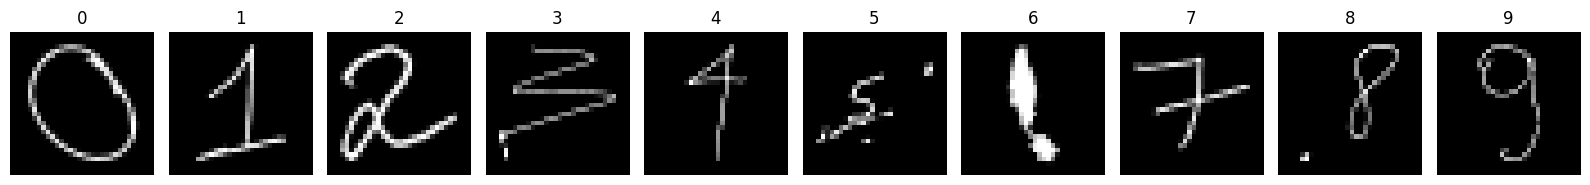

In [19]:
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for i, d in enumerate(sorted(os.listdir(RAW_LABELED_DIR))):
    folder = os.path.join(RAW_LABELED_DIR, d)
    files_in_folder = sorted(os.listdir(folder))
    if not files_in_folder:
        continue
    arr, reason = process_one(os.path.join(folder, files_in_folder[0]))
    axes[i].imshow(arr if arr is not None else np.zeros((32, 32)), cmap="gray")
    axes[i].set_title(d if arr is not None else f"{d} (rej)")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## Step 2b — Run the pipeline over the full dataset

In [20]:
X, y, rejects = [], [], []

for label in sorted(os.listdir(RAW_LABELED_DIR)):
    folder = os.path.join(RAW_LABELED_DIR, label)
    if not os.path.isdir(folder):
        continue
    for fname in sorted(os.listdir(folder)):
        arr, reason = process_one(os.path.join(folder, fname))
        if arr is None:
            rejects.append((label, fname, reason))
            continue
        X.append(arr)
        y.append(int(label))

X = np.stack(X).astype(np.float32)
y = np.array(y, dtype=np.int64)

print(f"Kept {len(y)} images, rejected {len(rejects)}")
print("Per-class counts (post quality-control):",
      {c: int((y == c).sum()) for c in range(10)})

if rejects:
    print(f"\nFirst few rejections (of {len(rejects)}):")
    for r in rejects[:10]:
        print(" ", r)

np.savez_compressed("/content/dataset.npz", X=X, y=y)
print("\nSaved dataset to /content/dataset.npz")


Kept 532 images, rejected 55
Per-class counts (post quality-control): {0: 39, 1: 37, 2: 69, 3: 40, 4: 85, 5: 79, 6: 59, 7: 34, 8: 47, 9: 43}

First few rejections (of 55):
  ('0', '0_002.jpg', 'no digit detected')
  ('1', '1001 (10).jpg', 'no digit detected')
  ('1', '1001 (12).jpg', 'no digit detected')
  ('1', '1001 (13).jpg', 'no digit detected')
  ('1', '1001 (14).jpg', 'no digit detected')
  ('1', '1001 (23).jpg', 'no digit detected')
  ('1', '1001 (36).jpg', 'no digit detected')
  ('1', '1001 (37).jpg', 'no digit detected')
  ('1', '1001 (38).jpg', 'no digit detected')
  ('1', '1001 (44).jpg', 'no digit detected')

Saved dataset to /content/dataset.npz


## Step 3 — Train / validation / test split

Stratified 70/15/15 split, done **before** any augmentation, so validation
and test stay real, untouched photos.


In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f"Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}")


Train: 372  Val: 80  Test: 80


## Step 4 — Augmentation (training set only)

Random rotation, shift, zoom, mild shear, and occasional light noise —
applied only to the training split, balancing every class up to
`TARGET_PER_CLASS` samples.


Augmented training set: (2600, 32, 32)
Per-class counts after augmentation: {0: 260, 1: 260, 2: 260, 3: 260, 4: 260, 5: 260, 6: 260, 7: 260, 8: 260, 9: 260}


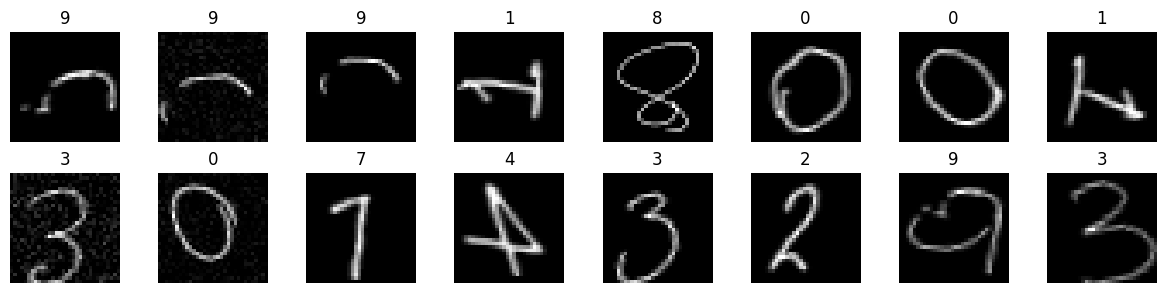

In [22]:
def augment_image(img):
    """img: float32 32x32 in [0,1]. Returns an augmented copy."""
    h, w = img.shape
    angle = np.random.uniform(-15, 15)
    tx = np.random.uniform(-0.10, 0.10) * w
    ty = np.random.uniform(-0.10, 0.10) * h
    scale = np.random.uniform(0.85, 1.15)

    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    out = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)

    shear = np.random.uniform(-0.15, 0.15)
    S = np.float32([[1, shear, -shear * h / 2], [0, 1, 0]])
    out = cv2.warpAffine(out, S, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)

    if np.random.rand() < 0.3:
        noise = np.random.normal(0, 0.03, out.shape).astype(np.float32)
        out = np.clip(out + noise, 0, 1)

    return out.astype(np.float32)


TARGET_PER_CLASS = 260

aug_X, aug_y = [], []
for c in range(10):
    idx = np.where(y_train == c)[0]
    class_imgs = X_train[idx]
    aug_X.extend(class_imgs)
    aug_y.extend([c] * len(class_imgs))
    for _ in range(max(0, TARGET_PER_CLASS - len(class_imgs))):
        base = class_imgs[np.random.randint(len(class_imgs))]
        aug_X.append(augment_image(base))
        aug_y.append(c)

X_train_aug = np.stack(aug_X).astype(np.float32)
y_train_aug = np.array(aug_y, dtype=np.int64)
perm = np.random.permutation(len(y_train_aug))
X_train_aug, y_train_aug = X_train_aug[perm], y_train_aug[perm]

print("Augmented training set:", X_train_aug.shape)
print("Per-class counts after augmentation:",
      {c: int((y_train_aug == c).sum()) for c in range(10)})

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_aug[i], cmap="gray")
    ax.set_title(str(y_train_aug[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

Xtr = X_train_aug[..., None]
Xva = X_val[..., None]
Xte = X_test[..., None]


## Step 5 — Build the CNN

Kept deliberately small (~34K parameters) given the dataset size —
two conv+pool blocks are plenty for 32×32 single-digit images, and a
bigger network would just overfit ~350 training photos.


In [23]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 1)),
    layers.Conv2D(8, 3, padding="same", activation="relu", name="conv1"),
    layers.MaxPooling2D(2, name="pool1"),
    layers.Conv2D(16, 3, padding="same", activation="relu", name="conv2"),
    layers.MaxPooling2D(2, name="pool2"),
    layers.Flatten(),
    layers.Dense(32, activation="relu", name="dense1"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax", name="dense2"),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,378 (134.29 KB)

 Trainable params: 34,378 (134.29 KB)

 Non-trainable params: 0 (0.00 B)

Train with early stopping (on validation accuracy) and LR reduction on plateau:

In [24]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15,
                                   restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6),
]

history = model.fit(
    Xtr, y_train_aug,
    validation_data=(Xva, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/80
82/82 - 4s - 54ms/step - accuracy: 0.2250 - loss: 2.0755 - val_accuracy: 0.4875 - val_loss: 1.5338 - learning_rate: 0.0010
Epoch 2/80
82/82 - 2s - 26ms/step - accuracy: 0.4512 - loss: 1.5999 - val_accuracy: 0.6000 - val_loss: 1.1758 - learning_rate: 0.0010
Epoch 3/80
82/82 - 2s - 19ms/step - accuracy: 0.5315 - loss: 1.3619 - val_accuracy: 0.6875 - val_loss: 1.0202 - learning_rate: 0.0010
Epoch 4/80
82/82 - 1s - 18ms/step - accuracy: 0.5808 - loss: 1.2268 - val_accuracy: 0.7000 - val_loss: 0.8968 - learning_rate: 0.0010
Epoch 5/80
82/82 - 2s - 19ms/step - accuracy: 0.6335 - loss: 1.0680 - val_accuracy: 0.7000 - val_loss: 0.8160 - learning_rate: 0.0010
Epoch 6/80
82/82 - 1s - 18ms/step - accuracy: 0.6750 - loss: 0.9547 - val_accuracy: 0.7375 - val_loss: 0.8113 - learning_rate: 0.0010
Epoch 7/80
82/82 - 2s - 23ms/step - accuracy: 0.6988 - loss: 0.8875 - val_accuracy: 0.7625 - val_loss: 0.7226 - learning_rate: 0.0010
Epoch 8/80
82/82 - 3s - 32ms/step - accuracy: 0.7235 - loss: 0

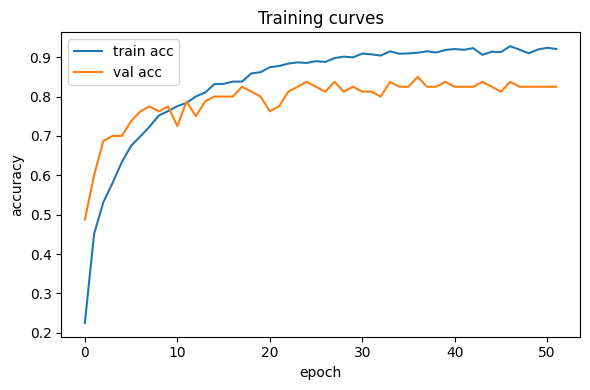

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("Training curves")
plt.tight_layout()
plt.show()


## Step 6 — Evaluate on the untouched test set

TEST accuracy: 0.7750  |  TEST loss: 1.0530
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         6
           1      0.750     1.000     0.857         6
           2      0.700     0.700     0.700        10
           3      0.833     0.833     0.833         6
           4      0.727     0.615     0.667        13
           5      0.556     0.417     0.476        12
           6      1.000     1.000     1.000         9
           7      0.625     1.000     0.769         5
           8      0.833     0.714     0.769         7
           9      0.857     1.000     0.923         6

    accuracy                          0.775        80
   macro avg      0.788     0.828     0.799        80
weighted avg      0.772     0.775     0.766        80



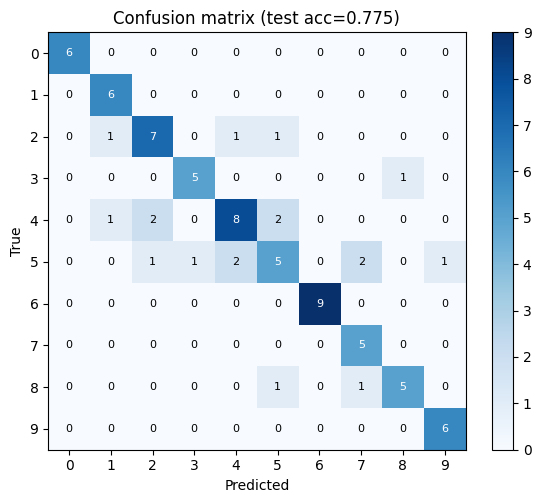

In [26]:
test_loss, test_acc = model.evaluate(Xte, y_test, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}  |  TEST loss: {test_loss:.4f}")

y_pred_probs = model.predict(Xte, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix (test acc={test_acc:.3f})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(10)); plt.yticks(range(10))
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 7 — Save the model and export weights for deployment

We save the Keras model itself, and also export the learned weights to
plain JSON — that's what powers the browser demo in Step 8 (a hand-written
JS forward pass, no server, no ML runtime dependency).


In [27]:
model.save("/content/digit_cnn.keras")

weights_json = {"layers": []}
for layer in model.layers:
    w = layer.get_weights()
    if not w:
        continue
    entry = {"name": layer.name, "type": layer.__class__.__name__}
    kernel, bias = w
    entry["kernel_shape"] = list(kernel.shape)
    entry["kernel"] = kernel.tolist()
    entry["bias"] = bias.tolist()
    weights_json["layers"].append(entry)

with open("/content/digit_cnn_weights.json", "w") as f:
    json.dump(weights_json, f)

print("Saved /content/digit_cnn.keras and /content/digit_cnn_weights.json")


Saved /content/digit_cnn.keras and /content/digit_cnn_weights.json


## Step 8 — Deploy: build a self-contained, working HTML demo

This generates a single `.html` file with:
- the exported model weights embedded as JSON,
- a hand-written JavaScript CNN forward pass (conv2d → maxpool → conv2d →
  maxpool → dense → dense → softmax) that exactly mirrors the trained
  architecture — no TensorFlow.js or other runtime needed,
- a canvas you can draw a digit on, with client-side preprocessing
  (crop → center → resize → normalize) mirroring the training pipeline.

Open the downloaded file in any browser — it works completely offline.


In [28]:
inference_js = r"""
function conv2dSame(input, H, W, C, kernel, bias, kh, kw, outC) {
  const padH = Math.floor(kh / 2);
  const padW = Math.floor(kw / 2);
  const out = new Float32Array(H * W * outC);
  for (let y = 0; y < H; y++) {
    for (let x = 0; x < W; x++) {
      for (let oc = 0; oc < outC; oc++) {
        let sum = bias[oc];
        for (let ky = 0; ky < kh; ky++) {
          const iy = y + ky - padH;
          if (iy < 0 || iy >= H) continue;
          for (let kx = 0; kx < kw; kx++) {
            const ix = x + kx - padW;
            if (ix < 0 || ix >= W) continue;
            const inBase = (iy * W + ix) * C;
            const kBase = kernel[ky][kx];
            for (let ic = 0; ic < C; ic++) {
              sum += input[inBase + ic] * kBase[ic][oc];
            }
          }
        }
        out[(y * W + x) * outC + oc] = Math.max(0, sum);
      }
    }
  }
  return out;
}

function maxPool2(input, H, W, C) {
  const outH = Math.floor(H / 2);
  const outW = Math.floor(W / 2);
  const out = new Float32Array(outH * outW * C);
  for (let y = 0; y < outH; y++) {
    for (let x = 0; x < outW; x++) {
      for (let c = 0; c < C; c++) {
        let m = -Infinity;
        for (let dy = 0; dy < 2; dy++) {
          for (let dx = 0; dx < 2; dx++) {
            const iy = y * 2 + dy, ix = x * 2 + dx;
            const v = input[(iy * W + ix) * C + c];
            if (v > m) m = v;
          }
        }
        out[(y * outW + x) * C + c] = m;
      }
    }
  }
  return { data: out, H: outH, W: outW };
}

function denseForward(input, kernel, bias, inDim, outDim, activation) {
  const out = new Float32Array(outDim);
  for (let o = 0; o < outDim; o++) {
    let sum = bias[o];
    for (let i = 0; i < inDim; i++) sum += input[i] * kernel[i][o];
    out[o] = sum;
  }
  if (activation === "relu") for (let i = 0; i < outDim; i++) out[i] = Math.max(0, out[i]);
  return out;
}

function softmax(logits) {
  const m = Math.max(...logits);
  const exps = logits.map((v) => Math.exp(v - m));
  const s = exps.reduce((a, b) => a + b, 0);
  return exps.map((v) => v / s);
}

function forwardPass(weights, input32) {
  const byName = {};
  for (const l of weights.layers) byName[l.name] = l;

  const c1 = byName["conv1"];
  let x = conv2dSame(input32, 32, 32, 1, c1.kernel, c1.bias, 3, 3, 8);
  let H = 32, W = 32, C = 8;

  let p = maxPool2(x, H, W, C);
  x = p.data; H = p.H; W = p.W;

  const c2 = byName["conv2"];
  x = conv2dSame(x, H, W, C, c2.kernel, c2.bias, 3, 3, 16);
  C = 16;

  p = maxPool2(x, H, W, C);
  x = p.data; H = p.H; W = p.W;

  const flat = x;
  const d1 = byName["dense1"];
  const h1 = denseForward(flat, d1.kernel, d1.bias, H * W * C, 32, "relu");
  const d2 = byName["dense2"];
  const logits = denseForward(h1, d2.kernel, d2.bias, 32, 10, null);

  return softmax(Array.from(logits));
}
"""

with open("/content/digit_cnn_weights.json") as f:
    weights_json_str = f.read()

test_acc_pct = f"{test_acc*100:.1f}%"

html = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Handwritten Digit Recognizer</title>
<style>
  :root { --bg:#0f1115; --panel:#171a21; --accent:#6ea8fe; --accent-dim:#3a5a8c;
          --text:#e8eaed; --muted:#9aa0a6; --bar-bg:#262a33; }
  * { box-sizing: border-box; }
  body { margin:0; font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,Helvetica,Arial,sans-serif;
         background:var(--bg); color:var(--text); display:flex; justify-content:center; padding:28px 16px 48px; }
  .wrap { width:100%; max-width:760px; }
  h1 { font-size:1.4rem; margin:0 0 4px; }
  .subtitle { color:var(--muted); font-size:0.9rem; margin-bottom:20px; }
  .card { background:var(--panel); border-radius:14px; padding:20px; margin-bottom:16px; border:1px solid #262a33; }
  .layout { display:flex; gap:20px; flex-wrap:wrap; }
  .canvas-col { display:flex; flex-direction:column; align-items:center; gap:12px; }
  canvas#pad { background:#000; border-radius:10px; touch-action:none; cursor:crosshair; border:2px solid #2a2f3a; }
  .btn-row { display:flex; gap:10px; }
  button { background:var(--accent); color:#0b1220; border:none; border-radius:8px; padding:10px 16px; font-weight:600; font-size:0.9rem; cursor:pointer; }
  button.secondary { background:transparent; color:var(--text); border:1px solid #333945; }
  button:active { transform:translateY(1px); }
  .results-col { flex:1; min-width:220px; }
  .prediction { font-size:3.2rem; font-weight:700; color:var(--accent); line-height:1; margin-bottom:4px; }
  .pred-label { color:var(--muted); font-size:0.85rem; margin-bottom:14px; }
  .bar-row { display:flex; align-items:center; gap:8px; margin-bottom:6px; font-size:0.82rem; }
  .bar-label { width:14px; color:var(--muted); }
  .bar-track { flex:1; background:var(--bar-bg); border-radius:4px; height:14px; overflow:hidden; }
  .bar-fill { height:100%; background:var(--accent-dim); }
  .bar-fill.top { background:var(--accent); }
  .bar-pct { width:42px; text-align:right; color:var(--muted); }
  .preview { display:flex; align-items:center; gap:10px; margin-top:10px; }
  .preview canvas { image-rendering:pixelated; border:1px solid #333945; border-radius:4px; }
  .preview span { color:var(--muted); font-size:0.78rem; }
  .meta { color:var(--muted); font-size:0.8rem; line-height:1.5; }
  .badge { display:inline-block; background:#1d2733; color:var(--accent); border-radius:6px; padding:2px 8px; font-size:0.75rem; margin-right:6px; }
</style>
</head>
<body>
<div class="wrap">
  <h1>Handwritten Digit Recognizer</h1>
  <div class="subtitle">Small CNN trained from scratch &middot; runs entirely in this page, no server call</div>
  <div class="card">
    <div class="layout">
      <div class="canvas-col">
        <canvas id="pad" width="280" height="280"></canvas>
        <div class="btn-row">
          <button id="predictBtn">Predict</button>
          <button id="clearBtn" class="secondary">Clear</button>
        </div>
        <div class="preview" id="previewWrap" style="display:none;">
          <canvas id="preview32" width="32" height="32" style="width:96px;height:96px;"></canvas>
          <span>what the model actually sees<br>(32&times;32, centered, normalized)</span>
        </div>
      </div>
      <div class="results-col">
        <div id="predBig" class="prediction">&mdash;</div>
        <div id="predLabel" class="pred-label">draw a digit and hit Predict</div>
        <div id="bars"></div>
      </div>
    </div>
  </div>
  <div class="card meta">
    <span class="badge">test accuracy __TEST_ACC__</span>
    <span class="badge">34,378 params</span>
    <span class="badge">32&times;32 grayscale input</span>
    <br><br>
    Architecture: Conv(8,3&times;3)&rarr;MaxPool&rarr;Conv(16,3&times;3)&rarr;MaxPool&rarr;Dense(32)&rarr;Dense(10,softmax).
    The JavaScript below reimplements the exact trained architecture and weights, hand-ported from the Keras model.
  </div>
</div>
<script>const MODEL_WEIGHTS = __WEIGHTS_JSON__;</script>
<script>__INFERENCE_JS__</script>
<script>
const pad = document.getElementById("pad");
const ctx = pad.getContext("2d", { willReadFrequently: true });
ctx.fillStyle = "#000"; ctx.fillRect(0, 0, pad.width, pad.height);
ctx.strokeStyle = "#fff"; ctx.lineWidth = 18; ctx.lineCap = "round"; ctx.lineJoin = "round";

let drawing = false, lastX = 0, lastY = 0, hasInk = false;

function getPos(e) {
  const rect = pad.getBoundingClientRect();
  const scaleX = pad.width / rect.width, scaleY = pad.height / rect.height;
  if (e.touches && e.touches.length) return { x:(e.touches[0].clientX-rect.left)*scaleX, y:(e.touches[0].clientY-rect.top)*scaleY };
  return { x:(e.clientX-rect.left)*scaleX, y:(e.clientY-rect.top)*scaleY };
}
function start(e){ drawing=true; hasInk=true; const p=getPos(e); lastX=p.x; lastY=p.y; e.preventDefault(); }
function move(e){ if(!drawing) return; const p=getPos(e); ctx.beginPath(); ctx.moveTo(lastX,lastY); ctx.lineTo(p.x,p.y); ctx.stroke(); lastX=p.x; lastY=p.y; e.preventDefault(); }
function end(){ drawing=false; }

pad.addEventListener("mousedown", start);
pad.addEventListener("mousemove", move);
window.addEventListener("mouseup", end);
pad.addEventListener("touchstart", start, {passive:false});
pad.addEventListener("touchmove", move, {passive:false});
pad.addEventListener("touchend", end);

document.getElementById("clearBtn").addEventListener("click", () => {
  ctx.fillStyle = "#000"; ctx.fillRect(0, 0, pad.width, pad.height);
  hasInk = false;
  document.getElementById("predBig").textContent = "\u2014";
  document.getElementById("predLabel").textContent = "draw a digit and hit Predict";
  document.getElementById("bars").innerHTML = "";
  document.getElementById("previewWrap").style.display = "none";
});

function preprocessCanvasTo32() {
  const img = ctx.getImageData(0, 0, pad.width, pad.height);
  const W = pad.width, H = pad.height;
  let minX=W, minY=H, maxX=-1, maxY=-1;
  for (let y=0;y<H;y++) for (let x=0;x<W;x++) {
    const v = img.data[(y*W+x)*4];
    if (v > 20) { if(x<minX)minX=x; if(x>maxX)maxX=x; if(y<minY)minY=y; if(y>maxY)maxY=y; }
  }
  if (maxX < 0) return null;

  const w = maxX-minX+1, h = maxY-minY+1;
  const side = Math.max(w,h)*1.25;
  const cx = (minX+maxX)/2, cy = (minY+maxY)/2;

  const tmp = document.createElement("canvas");
  tmp.width = side; tmp.height = side;
  const tctx = tmp.getContext("2d");
  tctx.fillStyle = "#000"; tctx.fillRect(0,0,side,side);
  tctx.drawImage(pad, cx-side/2, cy-side/2, side, side, 0, 0, side, side);

  const small = document.getElementById("preview32");
  const sctx = small.getContext("2d");
  sctx.clearRect(0,0,32,32);
  sctx.drawImage(tmp, 0, 0, side, side, 0, 0, 32, 32);

  const small32 = sctx.getImageData(0, 0, 32, 32);
  const flat = new Float32Array(32*32);
  for (let i=0;i<32*32;i++) flat[i] = small32.data[i*4] / 255.0;
  document.getElementById("previewWrap").style.display = "flex";
  return flat;
}

document.getElementById("predictBtn").addEventListener("click", () => {
  if (!hasInk) return;
  const flat = preprocessCanvasTo32();
  if (!flat) return;
  const probs = forwardPass(MODEL_WEIGHTS, flat);
  let top = 0;
  for (let i=1;i<10;i++) if (probs[i] > probs[top]) top = i;
  document.getElementById("predBig").textContent = top;
  document.getElementById("predLabel").textContent = "confidence " + (probs[top]*100).toFixed(1) + "%";
  const barsDiv = document.getElementById("bars");
  barsDiv.innerHTML = "";
  const order = [...Array(10).keys()].sort((a,b) => probs[b]-probs[a]);
  for (const d of order) {
    const row = document.createElement("div");
    row.className = "bar-row";
    row.innerHTML = '<div class="bar-label">'+d+'</div>'+
      '<div class="bar-track"><div class="bar-fill'+(d===top?' top':'')+'" style="width:'+(probs[d]*100).toFixed(1)+'%"></div></div>'+
      '<div class="bar-pct">'+(probs[d]*100).toFixed(1)+'%</div>';
    barsDiv.appendChild(row);
  }
});
</script>
</body>
</html>
"""

html = html.replace("__TEST_ACC__", test_acc_pct)
html = html.replace("__WEIGHTS_JSON__", weights_json_str)
html = html.replace("__INFERENCE_JS__", inference_js)

with open("/content/digit_recognizer_demo.html", "w") as f:
    f.write(html)

print(f"Built digit_recognizer_demo.html ({len(html)/1024:.0f} KB)")


Built digit_recognizer_demo.html (744 KB)


Download everything (model, weights, and the working demo) to your machine:

In [29]:
from google.colab import files

files.download("/content/digit_cnn.keras")
files.download("/content/digit_cnn_weights.json")
files.download("/content/digit_recognizer_demo.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Done


